<a href="https://colab.research.google.com/github/aasikha/Week2-Basic-Data-Analysis-on-a-COVID-19-Dataset/blob/main/Week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Import Dataset
df = pd.read_csv("2019_nCoV_data.csv")

In [114]:
# Show info
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24709 entries, 0 to 24708
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   sno             24709 non-null  int64         
 1   date            24709 non-null  datetime64[ns]
 2   province/state  24709 non-null  object        
 3   country         24709 non-null  object        
 4   confirmed       24709 non-null  int64         
 5   deaths          24709 non-null  int64         
 6   recovered       24709 non-null  int64         
 7   day             24709 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(4), object(2)
memory usage: 1.5+ MB


In [ ]:
# Standardize column names (lowercase, underscores)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print("\nColumns after renaming:", df.columns.tolist())


Columns after renaming: ['sno', 'date', 'province/state', 'country', 'confirmed', 'deaths', 'recovered']


In [ ]:
# Drop duplicate rows
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")
df = df.drop_duplicates()


Number of duplicate rows: 0


In [ ]:
# Check for missing values
print("\nNull values per column:")
print(df.isnull().sum())


Null values per column:
sno                  0
date                 0
province/state    4082
country              0
confirmed            0
deaths               0
recovered            0
dtype: int64


In [ ]:
# Handle missing values:
for col in ['province/state']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

In [ ]:
print("\nNull values after cleaning:")
print(df.isnull().sum())
print("\nData cleaning completed successfully!")


Null values after cleaning:
sno               0
date              0
province/state    0
country           0
confirmed         0
deaths            0
recovered         0
dtype: int64

Data cleaning completed successfully!


# Basic EDA

In [ ]:
# 1. Show first 5 rows
print("Top 5 rows of the dataset:")
display(df.head())

Top 5 rows of the dataset:


,sno,date,province/state,country,confirmed,deaths,recovered
0,1,1/22/2020 12:00,Anhui,China,1,0,0
1,2,1/22/2020 12:00,Beijing,China,14,0,0
2,3,1/22/2020 12:00,Chongqing,China,6,0,0
3,4,1/22/2020 12:00,Fujian,China,1,0,0
4,5,1/22/2020 12:00,Gansu,China,0,0,0


In [ ]:
# 2. Summary statistics
print("\n Summary statistics:")
display(df[['confirmed','deaths','recovered']].describe())


 Summary statistics:


,confirmed,deaths,recovered
count,24709.000000,24709.000000,24709.000000
mean,284.015662,10.641507,94.259541
std,3247.033278,172.711165,1728.675580
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000
75%,15.000000,0.000000,0.000000
max,80589.000000,8215.000000,61201.000000


In [ ]:
# 3. Number of unique countries
num_countries = df['country'].nunique()
print(f"\nNumber of countries in dataset: {num_countries}")


Number of countries in dataset: 226


In [ ]:
# 4. Most affected countries (by confirmed cases)
most_affected = df.groupby('country')['confirmed'].max().sort_values(ascending=False).head(10)
print("\nTop 10 most affected countries (by confirmed cases):")
print(most_affected)


Top 10 most affected countries (by confirmed cases):
country
Italy             80589
China             67801
Mainland China    67760
Spain             57786
Germany           43938
Iran              29406
France            29155
US                21873
Switzerland       11811
United Kingdom    11658
Name: confirmed, dtype: int64


# Visualizations

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


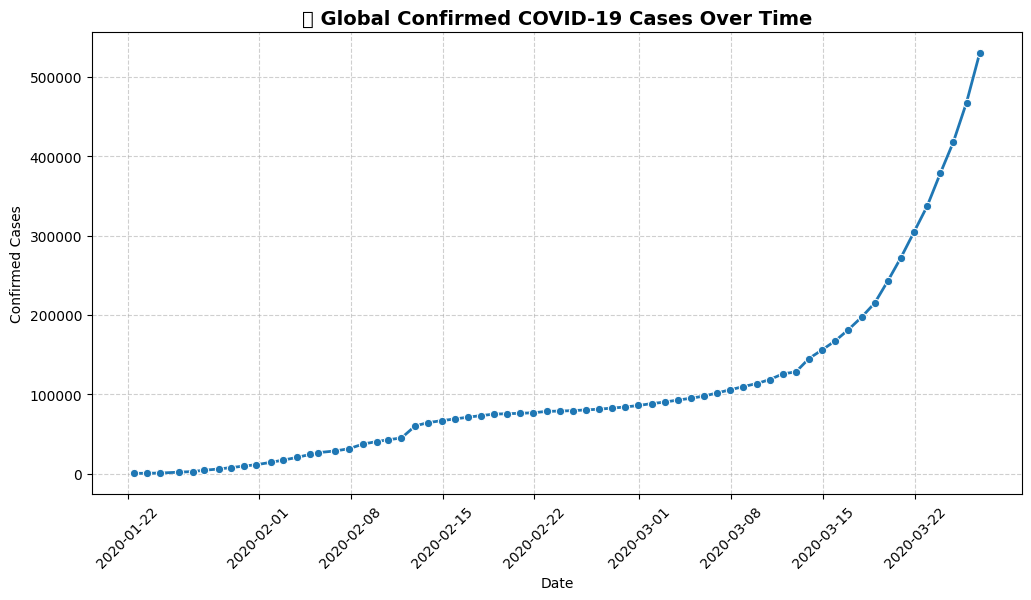

In [ ]:
# 1. Line chart for global confirmed cases over time

# Ensure 'date' column is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Group by date (global confirmed trend)
global_trend = df.groupby('date')['confirmed'].sum().reset_index()

# Plot
plt.figure(figsize=(12,6))
sns.lineplot(data=global_trend, x='date', y='confirmed', marker="o", linewidth=2)
plt.title("🌍 Global Confirmed COVID-19 Cases Over Time", fontsize=14, weight='bold')
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()




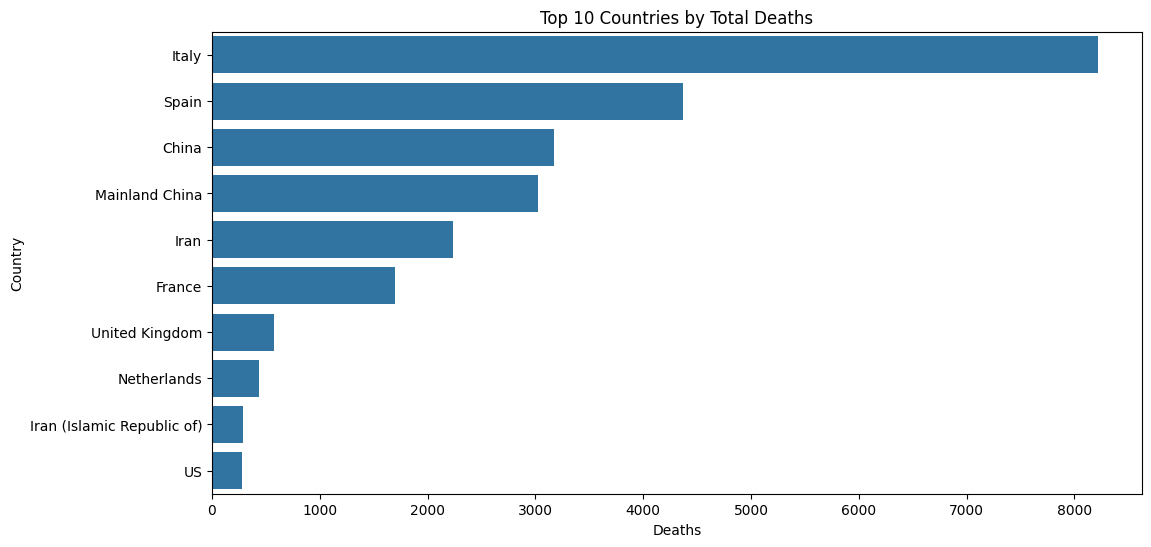

In [ ]:
# 2. Bar chart: top 10 countries with highest deaths
top_deaths = df.groupby('country')['deaths'].max().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_deaths.values, y=top_deaths.index)
plt.title("Top 10 Countries by Total Deaths")
plt.xlabel("Deaths")
plt.ylabel("Country")
plt.show()

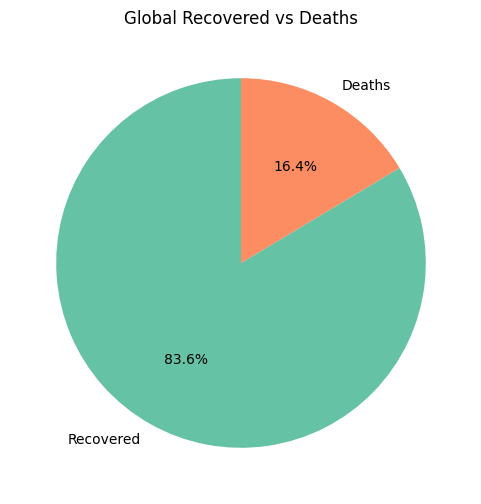

In [ ]:
# 3. Pie chart: global recovered vs deaths
latest = df[df['date'] == df['date'].max()].select_dtypes(include='number').sum()
recovered_total = latest['recovered']
deaths_total = latest['deaths']
plt.figure(figsize=(6,6))
plt.pie([recovered_total, deaths_total],
        labels=['Recovered','Deaths'],
        autopct='%1.1f%%', startangle=90, colors=['#66c2a5','#fc8d62'])
plt.title("Global Recovered vs Deaths")
plt.show()



# Observations


- Dataset contains information on confirmed cases, deaths, and recoveries, along with country/region, province/state, and dates.  
- Some missing values exist in the `Province/State` column.  
- Early outbreak was concentrated in China, especially Hubei province.  
- Top affected countries (latest date) include: **China, Italy, South Korea, Iran, USA**.  
- Global confirmed cases show an **exponential rise initially**, then plateau in some countries after interventions.  
- Recovery rate generally **lags behind confirmed cases**, while death rate varies by country.  
- **Line plot** shows trends of confirmed, deaths, and recovered cases over time globally.  
- **Pie chart** highlights the proportion of recovered vs deaths worldwide (latest date).  
- **Bar chart / heatmap** shows the top 10 countries with highest confirmed cases.  
- Dataset provides insights into spread patterns, mortality trends, and effectiveness of early interventions, but covers **early 2020 only**.
